# Portland D1 Demo

Let's start by loading in the Portland D1 CVR as a votekit PreferenceProfile. The below cell also lists some alternative profiles that are also accessible.

In [1]:
from votekit.pref_profile import PreferenceProfile
from votekit.ballot import Ballot
from votekit.cvr_loaders import load_scottish
from src.edouard.utils import convert_pf_to_numpy_arrays
from src.edouard.noise import bal_cvr_sample_constructor
from src.edouard.audit_machinery import project_matrix_onto_election_state, K_upper
from src.edouard.ranking_election.meek import MeekSTV, MeekCore
import numpy as np
import math
from statistics import NormalDist
from votekit.cleaning import remove_and_condense_rank_profile, remove_cand_rank_profile

#perth_kinross_profile = load_scottish("data/scot-elex/6_cands/perth_kinross_2012_ward9.csv")[0]
#other_scottish_profile = load_scottish("data/scot-elex/6_cands/east_ayrshire_2022_ward9.csv")[0]

D1_profile = PreferenceProfile.from_pickle("data/portland/Portland_D1.pkl")
#D2_profile = PreferenceProfile.from_pickle("data/portland/Portland_D2.pkl")
#D3_profile = PreferenceProfile.from_pickle("data/portland/Portland_D3.pkl")
#D4_profile = PreferenceProfile.from_pickle("data/portland/Portland_D4.pkl")

#D1_non_viable_cands = ["Joe Furi", "Thomas Shervey", "Cayle Tern", "Deian Salazar", "Michael (Mike) Sands", "Joe Allen", "David Linn", "Peggy Sue Owens"]
#D1_viable_profile = remove_and_condense_rank_profile(D1_non_viable_cands, D1_profile)

profile = D1_profile

Let's run the election to see the result according to the CVR:

In [4]:
num_ballots = profile.total_ballot_wt
print(num_ballots)
meek_elec = MeekSTV(profile, m=3, tiebreak="random")
meek_elec.get_score_df()

42678.0
Tie for lowest hopeful tallies among candidates [8, 10] with tally 1441.0. Running tiebreak.


,Round 0,Round 1,Round 2,Round 3,Round 4,Round 5,Round 6,Round 7,Round 8,Round 9,Round 10,Round 11,Round 12,Round 13,Round 14,Round 15
Candace Avalos,8307.0,8337.0,8368.0,8543.00,8637.00,8726.00,8789.0,8938.0,9237.0,9372.0,10649.00,9940.06,9630.60,9118.69,8933.47,8244.82
Loretta Smith,5595.0,5608.0,5634.0,5687.00,5767.00,5889.00,5999.0,6158.0,6399.0,6689.0,7198.00,7302.25,8573.18,10131.76,8933.47,8244.82
Jamie Dunphy,5068.0,5075.0,5108.0,5146.00,5180.00,5250.00,5303.0,5412.0,5483.0,5635.0,6079.00,6210.95,6881.95,9679.96,10158.52,8244.82
Noah Ernst,4060.0,4082.0,4095.0,4129.00,4190.00,4251.00,4360.0,4479.0,4642.0,5116.0,5658.00,5680.17,7090.44,7544.35,7708.41,8244.82
Steph Routh,3898.0,3904.0,3940.0,3997.00,4033.00,4095.00,4155.0,4266.0,4332.0,4500.0,5089.00,5346.17,6346.24,0.00,0.00,0.00
Terrence Hayes,3984.0,4003.0,4046.0,4078.00,4172.00,4251.00,4314.0,4445.0,4525.0,4847.0,5214.00,5280.64,0.00,0.00,0.00,0.00
Timur Ender,3556.0,3567.0,3586.0,3662.00,3699.00,3784.00,3861.0,3983.0,4187.0,4335.0,0.00,0.00,0.00,0.00,0.00,0.00
Doug Clove,1709.0,1736.0,1765.0,1795.00,1883.00,1977.00,2129.0,2302.0,2403.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00
Peggy Sue Owens,1269.0,1279.0,1294.0,1321.00,1333.00,1365.00,1441.0,1501.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00
David Linn,1113.0,1130.0,1150.0,1195.00,1226.00,1308.00,1441.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00


The below shows how the profile will get noised by the end-to-end synthetic auditing process. What this does is:
1) implicitly adds `num_ghosts` empty ballots to a pool of ballots that can be sampled by the auditor.
2) pre-emptively selects a number $j$ of indices out of the total weight $N$ of the profile to implicitly noise, such that $j/N =$ `noise_level`.
3) independently selects a number `sample_size` of indices for sampling without repetition. If and when the sampled indices collide with one of the noised indices, the sampler will replace the CVR ballot with a noised version.

To verify that this process produces the noise levels we're looking for, we can look at how many ballots from a given sample of 10,000 are discrepant (this is what this cell prints out).

In [15]:
num_ghosts= 150

ballot_matrix, mult_vec, _ = convert_pf_to_numpy_arrays(profile)
BAL, CVR = bal_cvr_sample_constructor(
    ballot_matrix,
    mult_vec,
    noise_level=0.02,
    sample_size=10000,
    num_ghosts=num_ghosts,
)
# find number of rows in BAL, CVR that are different;
num_discrepant = sum(np.any(BAL != CVR, axis=1))
print(num_discrepant, num_discrepant / len(BAL))

211 0.0211


Below is the graph constructor. The main thing we must specify is the "Least Auditable Margin" (LAM) for each election state degree. This can be thought of as twice the largest number of votes we could allow an adversary to perturb, and still remain confident that the election outcome would be the same. For Portland D1, this number is 532.

Tie for lowest hopeful tallies among candidates [8, 10] with tally 1441.0. Running tiebreak.


/home/nardo/research/meek/src/edouard/MeekGraph.py:445: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


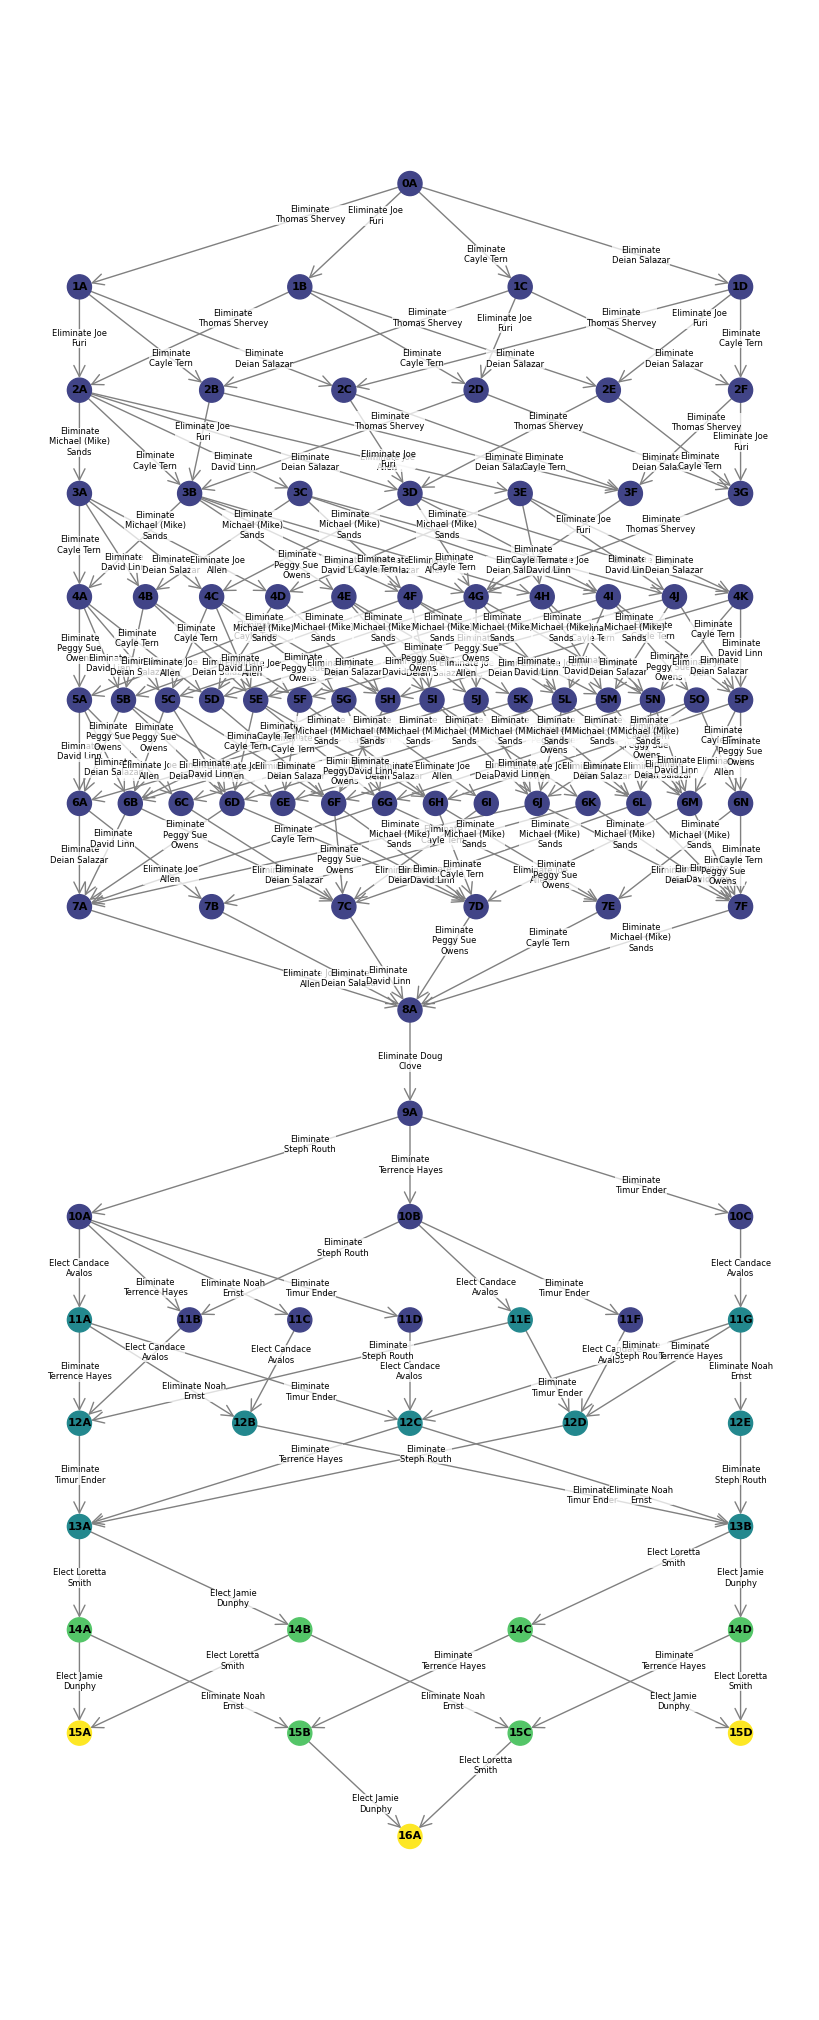

In [17]:
from src.edouard.MeekGraph import MeekGraph

audit_graph = MeekGraph(profile=profile, m=3, auditable_margins_per_deg=[532,532,532], use_numerical_labels=False)
audit_graph.plot_graph(figsize=(8,20), node_size=300, label_nodes=True, title=f"", label_edges=True, vertical_spacing=1000)

And this is the audit driver! Here's an outline of what it does:
1) Iterating through the vertices $v$ of the graph;
2) Lookup all the vertices in the next layer of the graph, using them to determine the 'allowable outcomes' from $v.$ -- we don't use the graph's edge structure for this, because sometimes the graph will be more conservative than it can afford to be and fail to draw edges between vertices it includes.
3) For each non-allowable outcome from $v$, build an assertion whose rejection would suffice to eliminate the corresponding edge.
4) Depending on the degree of $v$, use the appropriate statistical machinery to reject that edge.

If it succesfully rejects every non-allowable outcome during this iteration, the auditor will print "AUDIT PASSED"; otherwise it will re-audit the failed vertices with a verbose setting to show which edges cause the audit to fail.

In [19]:
from src.edouard.src.margin_audits import end_to_end_synthetic_audit_3seat

end_to_end_synthetic_audit_3seat(profile, audit_graph, int(profile.total_ballot_wt//100), sample_size_fraction=1/40, alpha=.05, noise_level=0.02, hypergeo_var_bounds = [],epsilon=1e-6, verbose=False)

Number of ballots N: 43104
Sample size n: 1077
using the following hypergeo_var_bounds: [0.0027375649591685224, 0.004338344469190795, 0.0057767260579064585, 0.0071223088344469195, 0.008398292501855977, 0.009651076466221232, 0.010880660727542688, 0.01208704528582034, 0.013270230141054195, 0.014453414996288048, 0.015613400148478099, 0.01675018559762435, 0.017886971046770603, 0.019023756495916852, 0.020137342242019303, 0.02125092798812175, 0.0223645137342242, 0.023478099480326652, 0.0245684855233853, 0.02565887156644395, 0.0267492576095026]
-------------------------- Auditing node 0A with degree 0 ------------------
-------------------------- Auditing node 10A with degree 0 ------------------
-------------------------- Auditing node 10B with degree 0 ------------------
-------------------------- Auditing node 10C with degree 0 ------------------
-------------------------- Auditing node 11A with degree 1 ------------------
-------------------------- Auditing node 11B with degree 0 --------

True